In [13]:
import numpy as np
import pandas as pd

url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

df = pd.read_csv(url)

In [14]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [15]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df = df[columns]

In [16]:
y_column = 'fuel_efficiency_mpg'

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

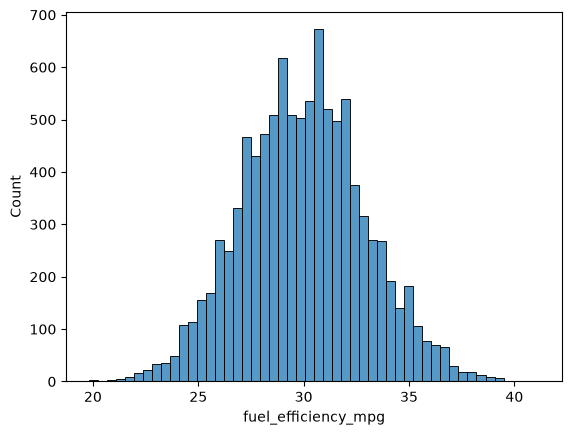

In [18]:
sns.histplot(df['fuel_efficiency_mpg'],bins=50)

Q1 — Missing values

In [20]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Q2 — Median horsepower

In [21]:
df.horsepower.median()

np.float64(254.0)

Prepare the split for Q3/Q4

In [23]:
n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [24]:
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [25]:
y_train = df_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

Q3 — Fill missing values with 0 vs mean

In [26]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [27]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error**2
    mse = se.mean()

    return np.sqrt(mse)

Option 1 — fill with zero

In [35]:
x_train_zero = df_train.fillna(0).values
x_val_zero = df_val.fillna(0).values

w0, w = train_linear_regression(x_train_zero, y_train)

y_pred = w0 + x_val_zero.dot(w)

score_zero = rmse(y_val, y_pred)

Option 2 — fill with training mean

In [36]:
mean_value = df_train['horsepower'].mean()

x_train_mean = df_train.fillna({'horsepower':mean_value}).values
x_val_mean = df_val.fillna({'horsepower':mean_value}).values

In [37]:
w0, w = train_linear_regression(x_train_mean,y_train)
y_pred = w0 + x_val_mean.dot(w)

score_mean = rmse(y_val, y_pred)

In [38]:
round(score_zero, 3), round(score_mean, 3)

(np.float64(2.205), np.float64(2.202))

Both are equally good

Q4 — Regularization

In [47]:
def train_linear_regression_reg(X, y, r=0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])

    XTX = X.T.dot(X)
    XTX = XTX + r*np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [48]:
X_train = df_train.fillna(0).values
X_val = df_val.fillna(0).values

In [49]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

In [50]:
for r in r_values:
    w0, w = train_linear_regression_reg(X_train,y_train,r)

    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)

    print(r, round(score,4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


Q5 — Effect of random seed

In [51]:
seeds = range(10)

In [52]:
scores = []

In [53]:
for seed in seeds:
    n = len(df)
    n_val = int(n*0.2)
    n_test = int(n*0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train_seed = df.iloc[idx[:n_train]].copy()
    df_val_seed = df.iloc[idx[n_train:n_train + n_val]].copy()

    y_train_seed = df_train_seed['fuel_efficiency_mpg'].values
    y_val_seed = df_val_seed['fuel_efficiency_mpg'].values

    del df_train_seed['fuel_efficiency_mpg']
    del df_val_seed['fuel_efficiency_mpg']

    X_train_seed = df_train_seed.fillna(0).values
    X_val_seed = df_val_seed.fillna(0).values

    w0, w = train_linear_regression(
        X_train_seed,
        y_train_seed
    )

    y_pred = w0 + X_val_seed.dot(w)

    score = rmse(y_val_seed, y_pred)

    scores.append(score)

    print(seed, score)

0 2.239204143046126
1 2.2021128210838845
2 2.1634197787530947
3 2.2043588768539224
4 2.2018800943311554
5 2.2457851509085134
6 2.2697212079524043
7 2.190794599933443
8 2.216611201686444
9 2.2070365928178957


In [54]:
std = np.std(scores)
round(std,3)

np.float64(0.029)

Q6 — Final model

In [62]:
seed = 9
r = 0.001

In [63]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

In [64]:
X_full_train = df_full_train.fillna(0).values
X_test = df_test.fillna(0).values

In [65]:
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)

round(score, 3)

np.float64(2.236)